In [2]:

import os
import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt
import pandas as pd
from scipy.signal import find_peaks
import warnings
warnings.filterwarnings('ignore')

In [4]:
sr = 16000 


audio_path = "test_healthy_voice.wav"



audio, sr = librosa.load(audio_path, sr=sr, mono=True)
duration = len(audio) / sr

print(f"Loaded: {audio_path}")
print(f"Duration: {duration:.2f} seconds")
print(f"Sample Rate: {sr} Hz")
print(f"Total samples: {len(audio)}")
print(audio)

Loaded: test_healthy_voice.wav
Duration: 2.00 seconds
Sample Rate: 16000 Hz
Total samples: 32000
[-0.00570679  0.0602417   0.09347534 ... -0.08816528 -0.05377197
  0.00192261]


In [5]:
def extract_basic_features(audio, sr):
    features = {}

    # Root Mean Square Energy
    rms = librosa.feature.rms(y=audio)[0]
    features['rms_mean'] = np.mean(rms)
    features['rms_std'] = np.std(rms)

    # Zero Crossing Rate (indicator of voicing)
    zcr = librosa.feature.zero_crossing_rate(audio)[0]
    features['zcr_mean'] = np.mean(zcr)
    features['zcr_std'] = np.std(zcr)

    # Spectral features
    spectral_centroid = librosa.feature.spectral_centroid(y=audio, sr=sr)[0]
    spectral_rolloff = librosa.feature.spectral_rolloff(y=audio, sr=sr)[0]
    spectral_bandwidth = librosa.feature.spectral_bandwidth(y=audio, sr=sr)[0]

    features['spectral_centroid_mean'] = np.mean(spectral_centroid)
    features['spectral_rolloff_mean'] = np.mean(spectral_rolloff)
    features['spectral_bandwidth_mean'] = np.mean(spectral_bandwidth)

    return features


In [7]:
basic_features = extract_basic_features(audio, sr)
print("Basic features extracted:")
print(basic_features)
for k, v in basic_features.items():
    print(f"  {k}: {v:.4f}")


Basic features extracted:
{'rms_mean': np.float32(0.5436252), 'rms_std': np.float32(0.02639519), 'zcr_mean': np.float64(0.018391927083333332), 'zcr_std': np.float64(0.001548974976743533), 'spectral_centroid_mean': np.float64(875.0394885977406), 'spectral_rolloff_mean': np.float64(1694.8164682539682), 'spectral_bandwidth_mean': np.float64(1803.0829093282593)}
  rms_mean: 0.5436
  rms_std: 0.0264
  zcr_mean: 0.0184
  zcr_std: 0.0015
  spectral_centroid_mean: 875.0395
  spectral_rolloff_mean: 1694.8165
  spectral_bandwidth_mean: 1803.0829


In [8]:
def extract_pitch_and_voice_quality(audio, sr):
    features = {}

    # Pitch extraction using PYIN algorithm (more robust for voice)
    f0, voiced_flag, voiced_probs = librosa.pyin(
        audio, 
        fmin=librosa.note_to_hz('C2'),  # 65 Hz
        fmax=librosa.note_to_hz('C6')   # 1047 Hz
    )

    # Filter to only voiced segments
    f0_voiced = f0[voiced_flag]

    if len(f0_voiced) > 0:
        # Basic pitch statistics
        features['f0_mean'] = np.mean(f0_voiced)
        features['f0_std'] = np.std(f0_voiced)
        features['f0_min'] = np.min(f0_voiced)
        features['f0_max'] = np.max(f0_voiced)
        features['f0_median'] = np.median(f0_voiced)

        # Pitch stability measures
        features['f0_range'] = features['f0_max'] - features['f0_min']
        features['f0_variation'] = features['f0_std'] / features['f0_mean']

        print(f"Pitch extracted - Mean: {features['f0_mean']:.1f} Hz")
        print(f"  Voiced frames: {len(f0_voiced)} / {len(f0)}")
    else:
        print("No voiced segments detected for pitch analysis")
        f0_voiced = None

    return features, f0_voiced, f0, voiced_flag


In [9]:
pitch_features, f0_voiced, f0, voiced_flag = extract_pitch_and_voice_quality(audio, sr)
print("\nPitch features:")
for k, v in pitch_features.items():
    print(f"  {k}: {v:.4f}")


Pitch extracted - Mean: 207.0 Hz
  Voiced frames: 63 / 63

Pitch features:
  f0_mean: 207.0449
  f0_std: 0.5979
  f0_min: 206.4564
  f0_max: 207.6523
  f0_median: 206.4564
  f0_range: 1.1960
  f0_variation: 0.0029


In [15]:
def calculate_jitter(f0_voiced):
    features = {}

    if f0_voiced is None or len(f0_voiced) < 3:
        print("Insufficient voiced segments for jitter calculation")
        return features

    # Periods (inverse of F0)
    periods = 1.0 / f0_voiced

    # Jitter (relative) - average absolute difference between consecutive periods
    diffs = np.abs(np.diff(periods))
    print(f"diffs values are {diffs}.")
    if len(diffs) > 0:
        features['jitter_abs'] = np.mean(diffs)
        features['jitter_rel'] = np.mean(diffs) / np.mean(periods)
        features['jitter_percent'] = features['jitter_rel'] * 100

        print(f"Jitter calculated - Relative: {features['jitter_rel']:.4f}")
        print(f"  Jitter percent: {features['jitter_percent']:.3f}%")

    return features


jitter_features = calculate_jitter(f0_voiced)


diffs values are [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 2.78973058e-05 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 2.78973058e-05 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 2.78973058e-05
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 2.78973058e-05 0.00000000e+00 0.00000000e+00
 0.00000000e+00 2.78973058e-05 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 2.78973058e-05
 0.00000000e+00 0.00000000e+00 0.00000000e+00 2.78973058e-05
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 2.78973058e-05 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 2.78973058e-05
 0.00000000e+00 0.00000000e+00 0.00000000e+00 2.78973058e-05
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 2.78973058e-05 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00].
Jitter calculated - Relative: 0.001

In [17]:
def calculate_shimmer(audio, sr, f0_voiced, f0, voiced_flag):
    features = {}

    if f0_voiced is None or len(f0_voiced) < 3:
        print("Insufficient voiced segments for shimmer calculation")
        return features

    # Extract amplitude envelope from voiced segments
    hop_length = 512
    frame_length = 2048
    rms = librosa.feature.rms(y=audio, frame_length=frame_length, hop_length=hop_length)[0]

    # Map pitch times to RMS frames
    f0_times = librosa.times_like(f0, sr=sr, hop_length=hop_length)
    rms_times = librosa.times_like(rms, sr=sr, hop_length=hop_length)

    # Get amplitudes at voiced frames (map each voiced F0 time to nearest RMS frame)
    voiced_indices = []
    for t in f0_times[voiced_flag]:
        idx = np.argmin(np.abs(rms_times - t))
        voiced_indices.append(idx)

    # Remove duplicates while preserving order
    voiced_indices = list(dict.fromkeys(voiced_indices))

    if len(voiced_indices) > 3:
        amplitudes = rms[voiced_indices]

        # Shimmer (amplitude perturbation)
        amp_diffs = np.abs(np.diff(amplitudes))
        if len(amp_diffs) > 0:
            features['shimmer_abs'] = np.mean(amp_diffs)
            features['shimmer_rel'] = np.mean(amp_diffs) / np.mean(amplitudes)
            features['shimmer_percent'] = features['shimmer_rel'] * 100

            print(f"Shimmer calculated - Relative: {features['shimmer_rel']:.4f}")
            print(f"  Shimmer percent: {features['shimmer_percent']:.3f}%")

    return features


shimmer_features = calculate_shimmer(audio, sr, f0_voiced, f0, voiced_flag)


Shimmer calculated - Relative: 0.0126
  Shimmer percent: 1.263%


In [18]:
def calculate_hnr(audio, sr):
    features = {}

    # Get spectrogram
    D = librosa.stft(audio)
    S, phase = librosa.magphase(D)

    # Energy across frequency bins (mean over time)
    energy_spectrum = np.mean(S, axis=1)

    if len(energy_spectrum) > 10:
        # Find peaks in spectrum (harmonics)
        peaks, _ = find_peaks(energy_spectrum, height=np.mean(energy_spectrum))
        peak_energy = np.sum(energy_spectrum[peaks]) if len(peaks) > 0 else 0

        # Noise energy = total - harmonic energy
        total_energy = np.sum(energy_spectrum)
        noise_energy = total_energy - peak_energy

        if noise_energy > 0:
            features['hnr'] = peak_energy / noise_energy
            features['hnr_db'] = 10 * np.log10(features['hnr'] + 1e-10)
            print(f"HNR calculated - Ratio: {features['hnr']:.2f}")
            print(f"  HNR in dB: {features['hnr_db']:.2f} dB")

    return features


hnr_features = calculate_hnr(audio, sr)


HNR calculated - Ratio: 0.58
  HNR in dB: -2.38 dB


In [19]:
def extract_mfccs(audio, sr, n_mfcc=13):
    features = {}

    mfccs = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=n_mfcc)

    # Store mean and std for each coefficient
    for i in range(n_mfcc):
        features[f'mfcc_{i+1}_mean'] = np.mean(mfccs[i])
        features[f'mfcc_{i+1}_std'] = np.std(mfccs[i])

    print(f"{n_mfcc} MFCCs extracted")
    print(f"  MFCC 1 mean: {features['mfcc_1_mean']:.2f}")
    print(f"  MFCC 2 mean: {features['mfcc_2_mean']:.2f}")

    return features, mfccs


mfcc_features, mfccs = extract_mfccs(audio, sr, n_mfcc=13)


13 MFCCs extracted
  MFCC 1 mean: -239.16
  MFCC 2 mean: 22.69


In [20]:
# Combine all features
all_features = {}
all_features.update(basic_features)
all_features.update(pitch_features)
all_features.update(jitter_features)
all_features.update(shimmer_features)
all_features.update(hnr_features)
all_features.update(mfcc_features)

print(f"Total features extracted: {len(all_features)}")
print("\nKey biomarker values:")
key_list = ['f0_mean', 'jitter_percent', 'shimmer_percent', 'hnr_db', 'rms_mean']
for key in key_list:
    if key in all_features:
        print(f"  {key}: {all_features[key]:.4f}")


Total features extracted: 48

Key biomarker values:
  f0_mean: 207.0449
  jitter_percent: 0.1025
  shimmer_percent: 1.2633
  hnr_db: -2.3774
  rms_mean: 0.5436


Visualization saved as 'vocal_biomarker_analysis.png'


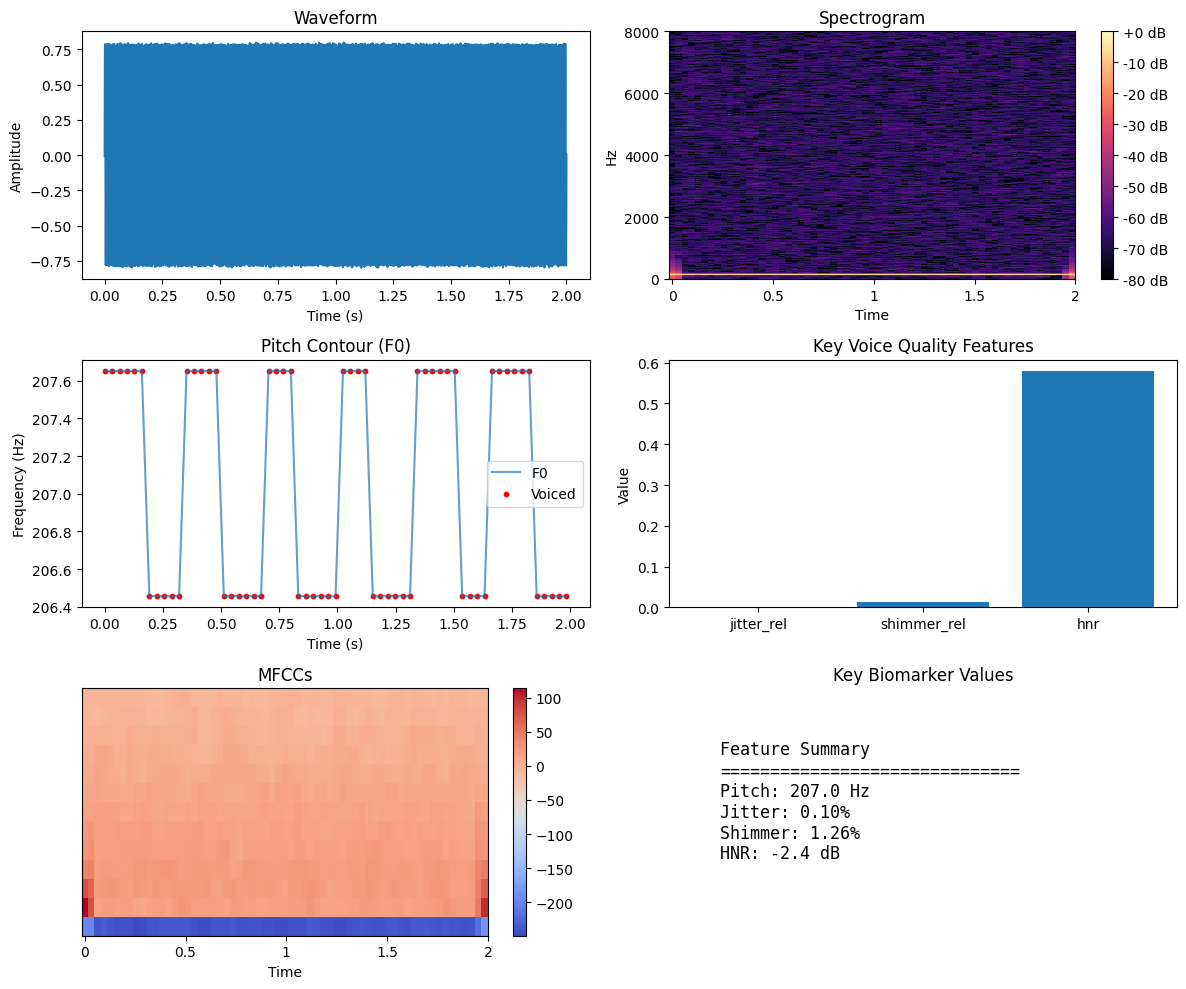

In [21]:
def visualize_features(audio, sr, f0_voiced, f0, voiced_flag, mfccs, all_features, duration):
    fig, axes = plt.subplots(3, 2, figsize=(12, 10))

    # 1. Waveform
    axes[0, 0].plot(np.linspace(0, duration, len(audio)), audio)
    axes[0, 0].set_title('Waveform')
    axes[0, 0].set_xlabel('Time (s)')
    axes[0, 0].set_ylabel('Amplitude')

    # 2. Spectrogram
    D = librosa.amplitude_to_db(np.abs(librosa.stft(audio)), ref=np.max)
    img = librosa.display.specshow(D, sr=sr, x_axis='time', y_axis='hz', ax=axes[0, 1])
    axes[0, 1].set_title('Spectrogram')
    plt.colorbar(img, ax=axes[0, 1], format='%+2.0f dB')

    # 3. Pitch contour
    if f0_voiced is not None and len(f0_voiced) > 0:
        times = librosa.times_like(f0, sr=sr)
        axes[1, 0].plot(times, f0, label='F0', alpha=0.7)
        axes[1, 0].scatter(times[voiced_flag], f0[voiced_flag], c='red', s=10, label='Voiced')
        axes[1, 0].set_title('Pitch Contour (F0)')
        axes[1, 0].set_xlabel('Time (s)')
        axes[1, 0].set_ylabel('Frequency (Hz)')
        axes[1, 0].legend()
    else:
        axes[1, 0].text(0.5, 0.5, 'No pitch detected', ha='center', va='center')
        axes[1, 0].set_title('Pitch Contour (F0)')

    # 4. Feature distribution (bar chart)
    feature_names = ['jitter_rel', 'shimmer_rel', 'hnr']
    feature_values = []
    labels = []
    for f in feature_names:
        if f in all_features:
            feature_values.append(all_features[f])
            labels.append(f)

    if feature_values:
        axes[1, 1].bar(labels, feature_values)
        axes[1, 1].set_title('Key Voice Quality Features')
        axes[1, 1].set_ylabel('Value')
    else:
        axes[1, 1].text(0.5, 0.5, 'No voice quality data', ha='center', va='center')

    # 5. MFCC heatmap
    img2 = librosa.display.specshow(mfccs, sr=sr, x_axis='time', ax=axes[2, 0])
    axes[2, 0].set_title('MFCCs')
    plt.colorbar(img2, ax=axes[2, 0])

    # 6. Feature summary
    summary_text = "Feature Summary\n"
    summary_text += "="*30 + "\n"
    for key in ['f0_mean', 'jitter_percent', 'shimmer_percent', 'hnr_db']:
        if key in all_features:
            if key == 'f0_mean':
                summary_text += f"Pitch: {all_features[key]:.1f} Hz\n"
            elif key == 'jitter_percent':
                summary_text += f"Jitter: {all_features[key]:.2f}%\n"
            elif key == 'shimmer_percent':
                summary_text += f"Shimmer: {all_features[key]:.2f}%\n"
            elif key == 'hnr_db':
                summary_text += f"HNR: {all_features[key]:.1f} dB\n"

    axes[2, 1].text(0.1, 0.5, summary_text, fontsize=12, verticalalignment='center', fontfamily='monospace')
    axes[2, 1].axis('off')
    axes[2, 1].set_title('Key Biomarker Values')

    plt.tight_layout()
    plt.savefig('vocal_biomarker_analysis.png', dpi=150, bbox_inches='tight')
    print("Visualization saved as 'vocal_biomarker_analysis.png'")
    plt.show()


visualize_features(audio, sr, f0_voiced, f0, voiced_flag, mfccs, all_features, duration)


In [22]:
def save_features(all_features, filename='vocal_features.csv'):
    df = pd.DataFrame([all_features])
    df.to_csv(filename, index=False)
    print(f"Features saved to '{filename}'")
    print(f"  Shape: {df.shape}")
    return df


df = save_features(all_features)
print("\nFirst few columns of the saved data:")
print(df.iloc[:, :8].to_string())


Features saved to 'vocal_features.csv'
  Shape: (1, 48)

First few columns of the saved data:
   rms_mean   rms_std  zcr_mean   zcr_std  spectral_centroid_mean  spectral_rolloff_mean  spectral_bandwidth_mean     f0_mean
0  0.543625  0.026395  0.018392  0.001549              875.039489            1694.816468              1803.082909  207.044862


In [24]:
def run_full_pipeline(audio_path, sr=16000):
    audio, sr = librosa.load(audio_path, sr=sr, mono=True)

    basic = extract_basic_features(audio, sr)
    pitch, f0_voiced, f0, voiced_flag = extract_pitch_and_voice_quality(audio, sr)
    jitter = calculate_jitter(f0_voiced)
    shimmer = calculate_shimmer(audio, sr, f0_voiced, f0, voiced_flag)
    hnr = calculate_hnr(audio, sr)
    mfcc, _ = extract_mfccs(audio, sr)

    all_f = {}
    all_f.update(basic)
    all_f.update(pitch)
    all_f.update(jitter)
    all_f.update(shimmer)
    all_f.update(hnr)
    all_f.update(mfcc)
    return all_f


healthy = run_full_pipeline("test_healthy_voice.wav")
patho = run_full_pipeline("test_pathological_voice.wav")

# Compare key biomarkers
print("\n" + "="*50)
print("COMPARISON: Healthy vs Pathological Voice")
print("="*50)
compare_keys = ['f0_mean', 'jitter_percent', 'shimmer_percent', 'hnr_db', 'rms_mean']
print(f"{'Feature':<20} {'Healthy':>12} {'Pathological':>12}")
print("-"*50)
for key in compare_keys:
    h_val = healthy.get(key, 0)
    p_val = patho.get(key, 0)
    print(f"{key:<20} {h_val:>12.4f} {p_val:>12.4f}")


Pitch extracted - Mean: 207.0 Hz
  Voiced frames: 63 / 63
diffs values are [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 2.78973058e-05 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 2.78973058e-05 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 2.78973058e-05
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 2.78973058e-05 0.00000000e+00 0.00000000e+00
 0.00000000e+00 2.78973058e-05 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 2.78973058e-05
 0.00000000e+00 0.00000000e+00 0.00000000e+00 2.78973058e-05
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 2.78973058e-05 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 2.78973058e-05
 0.00000000e+00 0.00000000e+00 0.00000000e+00 2.78973058e-05
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 2.78973058e-05 0.00000000e+00 0.00000000e+00
 0.0000000